In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [44]:
from sklearn.datasets import load_iris

iris = load_iris()

In [45]:
df = pd.read_csv('/kaggle/input/datasets/kaustubhbanga/iris-model/iris.csv')
df

,Unnamed: 0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,0,5.1,3.5,1.4,0.2,0
1,1,4.9,3.0,1.4,0.2,0
2,2,4.7,3.2,1.3,0.2,0
3,3,4.6,3.1,1.5,0.2,0
4,4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...,...
145,145,6.7,3.0,5.2,2.3,2
146,146,6.3,2.5,5.0,1.9,2
147,147,6.5,3.0,5.2,2.0,2
148,148,6.2,3.4,5.4,2.3,2


In [46]:
df.head()

,Unnamed: 0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,0,5.1,3.5,1.4,0.2,0
1,1,4.9,3.0,1.4,0.2,0
2,2,4.7,3.2,1.3,0.2,0
3,3,4.6,3.1,1.5,0.2,0
4,4,5.0,3.6,1.4,0.2,0


In [47]:
print(f"Shape of Data:{df.shape}")

Shape of Data:(150, 6)


In [48]:
print("Stastical Summary of Data:")
df.describe()

Stastical Summary of Data:


,Unnamed: 0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,74.500000,5.843333,3.057333,3.758000,1.199333,1.000000
std,43.445368,0.828066,0.435866,1.765298,0.762238,0.819232
min,0.000000,4.300000,2.000000,1.000000,0.100000,0.000000
25%,37.250000,5.100000,2.800000,1.600000,0.300000,0.000000
50%,74.500000,5.800000,3.000000,4.350000,1.300000,1.000000
75%,111.750000,6.400000,3.300000,5.100000,1.800000,2.000000
max,149.000000,7.900000,4.400000,6.900000,2.500000,2.000000


In [49]:
print(f"Info of Data:")
df.info()

Info of Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         150 non-null    int64  
 1   sepal length (cm)  150 non-null    float64
 2   sepal width (cm)   150 non-null    float64
 3   petal length (cm)  150 non-null    float64
 4   petal width (cm)   150 non-null    float64
 5   target             150 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 7.2 KB


In [50]:
#Changing Dtype of target
df["target"] = df["target"].astype(int)

In [51]:
df['target'].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

In [52]:
print(f"Missing Values in Data:\n{df.isnull().sum()}")

Missing Values in Data:
Unnamed: 0           0
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


**Encoding to target:**

In [53]:
df["Species"]=df["target"].map({0:"setosa",2:"virginica",1:"versicolor"})

In [54]:
df.head()

,Unnamed: 0,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Species
0,0,5.1,3.5,1.4,0.2,0,setosa
1,1,4.9,3.0,1.4,0.2,0,setosa
2,2,4.7,3.2,1.3,0.2,0,setosa
3,3,4.6,3.1,1.5,0.2,0,setosa
4,4,5.0,3.6,1.4,0.2,0,setosa


In [55]:
df.columns

Index(['Unnamed: 0', 'sepal length (cm)', 'sepal width (cm)',
       'petal length (cm)', 'petal width (cm)', 'target', 'Species'],
      dtype='object')

**Exploratory Data Analysis**

<Axes: xlabel='Species', ylabel='petal length (cm)'>

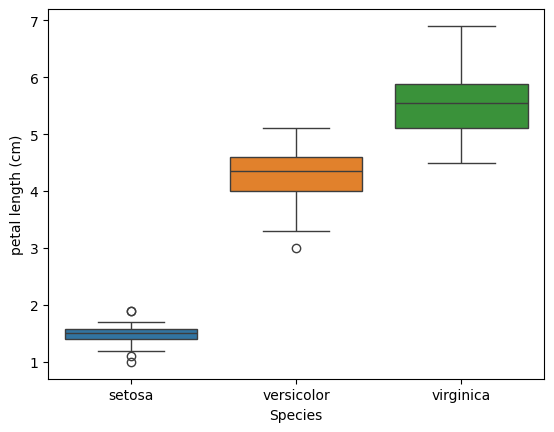

In [56]:
sns.boxplot(x="Species",y="petal length (cm)",data=df,hue="Species")

In [57]:
X = df[iris.feature_names]
y = df["target"]

**Splitting Data into Train set and Test set**

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")
print(f"y_train shape:{y_train.shape}")
print(f"y_test shape:{y_test.shape}")

X_train shape:(120, 4)
X_test shape:(30, 4)
y_train shape:(120,)
y_test shape:(30,)


**Traning Different Classification Models**

In [60]:
#models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Evaluation Metrics:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

**1. Logistic Regression**

In [61]:
lor = LogisticRegression(max_iter=200)
lor.fit(X_train,y_train)

LogisticRegression(max_iter=200)

In [62]:
y_pred_lr = lor.predict(X_test)

In [63]:
accuracy_lor = accuracy_score(y_test, y_pred_lr)
precision_lor = precision_score(y_test, y_pred_lr, average='macro')
recall_lor = recall_score(y_test, y_pred_lr, average='macro')
f1_lor = f1_score(y_test, y_pred_lr, average='macro')

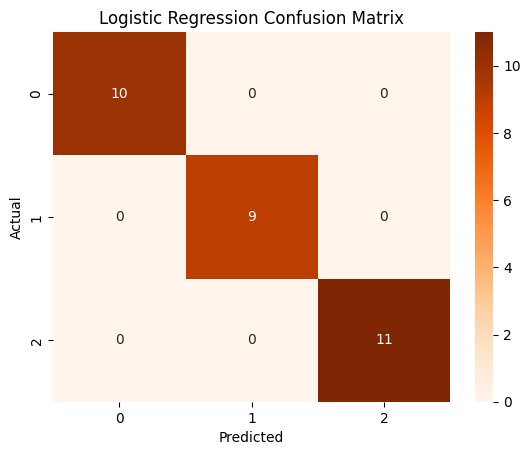

In [64]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**2. Decision Tree Classifier:**

In [65]:
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [66]:
y_pred_dt = dtc.predict(X_test)

In [67]:
accuracy_dtc = accuracy_score(y_test,y_pred_dt)
precision_dtc = precision_score(y_test, y_pred_dt, average='macro')
recall_dtc = recall_score(y_test, y_pred_dt, average='macro')
f1_dtc = f1_score(y_test, y_pred_dt, average='macro')

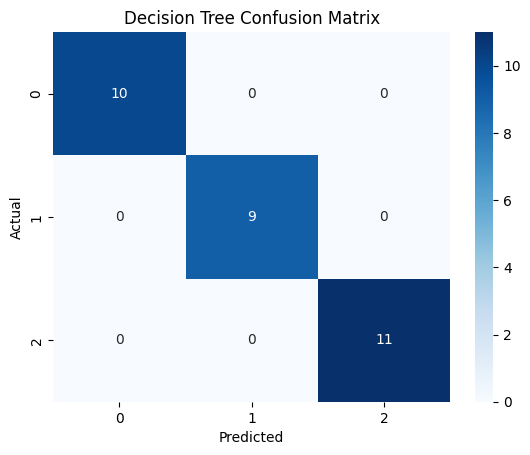

In [68]:
cm_dtc = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dtc, annot=True, fmt='d', cmap='Blues')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**3. Random Forest Clasifier**

In [69]:
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [70]:
y_pred_rf = rfc.predict(X_test)

In [71]:
accuracy_rfc = accuracy_score(y_test, y_pred_rf)
precision_rfc = precision_score(y_test, y_pred_rf, average='macro')
recall_rfc = recall_score(y_test, y_pred_rf, average='macro')
f1_rfc = f1_score(y_test, y_pred_rf, average='macro')

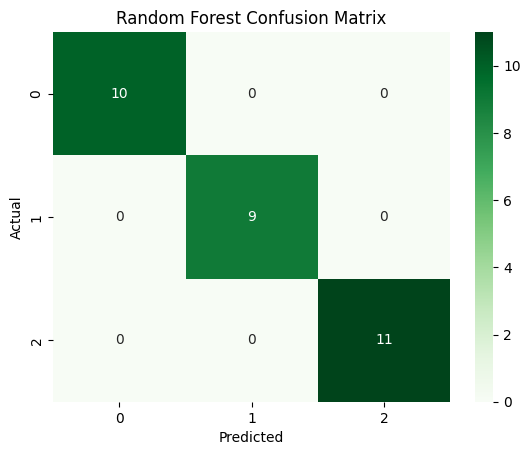

In [72]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Create a Evaluation Comparing DataFrame for all the Models:**

In [73]:
comp_df = pd.DataFrame({
    'Model':['Logistic Regression', 'Decision Tree Classifier', 'Random Forest Classifier'],
    'Accuracy':[accuracy_lor, accuracy_dtc, accuracy_rfc],
    'Precision':[precision_lor, precision_dtc, precision_rfc],
    'Recall':[recall_lor, recall_dtc, recall_rfc],
    'F1 Score':[f1_lor, f1_dtc, f1_rfc]
})

comp_df.set_index('Model'),round(3)

(                          Accuracy  Precision  Recall  F1 Score
 Model                                                          
 Logistic Regression            1.0        1.0     1.0       1.0
 Decision Tree Classifier       1.0        1.0     1.0       1.0
 Random Forest Classifier       1.0        1.0     1.0       1.0,
 3)

**Joblib to export and use model again**

In [74]:
import joblib 
import os
os.makedirs("models",exist_ok=True)

In [75]:
print(f"Saving Model:{joblib.dump(lor,"models/iris_logistic_regression.pkl")}")
print(f"Saving Model:{joblib.dump(dtc,"models/iris_decision_tree_classifier.pkl")}")
print(f"Saving Model:{joblib.dump(rfc,"models/iris_random_forest_classifier.pkl")}")

Saving Model:['models/iris_logistic_regression.pkl']
Saving Model:['models/iris_decision_tree_classifier.pkl']
Saving Model:['models/iris_random_forest_classifier.pkl']


In [76]:
loaded_lor = joblib.load("models/iris_logistic_regression.pkl")
loaded_dtc = joblib.load("models/iris_decision_tree_classifier.pkl")
loaded_rfc = joblib.load("models/iris_random_forest_classifier.pkl")

**Testing Models Prediction on New Sample**

In [77]:
df.columns

Index(['Unnamed: 0', 'sepal length (cm)', 'sepal width (cm)',
       'petal length (cm)', 'petal width (cm)', 'target', 'Species'],
      dtype='object')

In [78]:
new_sample = pd.DataFrame(
    [
        {
            "sepal length (cm)":5.1,
            "sepal width (cm)":3.5,
            "petal length (cm)":1.4,
            "petal width (cm)":0.2
        }
    ]
)

In [79]:
print("Models Prediction on new sample: \n")
print("Logistic Regression:",iris["target_names"][loaded_lor.predict(new_sample)[0]])
print("Decision Tree Classifier:",iris["target_names"][loaded_dtc.predict(new_sample)[0]])
print("Random Forest Classifier:",iris["target_names"][loaded_rfc.predict(new_sample)[0]])

Models Prediction on new sample: 

Logistic Regression: setosa
Decision Tree Classifier: setosa
Random Forest Classifier: setosa
